In [21]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

import pandas as pd

In [4]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/realAnalysis/tuberculosis")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [5]:
def get_final_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.mean(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

## IMC

In [29]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_imc.gz']

In [30]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [31]:
results

[[{'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 0,
   'val_score': 0.875,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 1,
   'val_score': 0.8051948051948052,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 2,
   'val_score': 0.986111111111111,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 3,
   'val_score': 0.7272727272727273,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 5,
   'cv': 4,
   'val_score': 0.8214285714285714,
   'test_score': 0.814957019583003},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 10,
   'cv': 0,
   'val_score': 0.8,
   'test_score': 0.8149562338301892},
  {'train_size': 0.001,
   'lamb': 0.0001,
   'rank': 10,
   'cv': 1,
   'val_score': 0.7638888888888888,
   'test_score': 0.8149562338301892},
  {'train_size': 0.001,
   'lam

In [32]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="lamb")
    )
results_final = np.array(results_final)
results_imc = np.mean(results_final, axis=0)

In [33]:
results_imc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.81513506, 0.91116569, 0.92186022, 0.93661297, 0.94045576,
        0.94385873, 0.94370521, 0.94642395, 0.9488162 , 0.94966757]])

## SGIMC

In [34]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_sgimc.gz']

In [35]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [36]:
results

[[{'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 0,
   'rank': 5,
   'val_score': 0.875,
   'val_d1': 496,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 1,
   'rank': 5,
   'val_score': 0.8051948051948051,
   'val_d1': 501,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 2,
   'rank': 5,
   'val_score': 0.986111111111111,
   'val_d1': 521,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 3,
   'rank': 5,
   'val_score': 0.7792207792207793,
   'val_d1': 423,
   'val_d2': 22,
   'test_score': 0.8153264805560491,
   'test_d1': 567,
   'test_d2': 22},
  {'train_size': 0.001,
   'C_group': 0.0001,
   'cv': 4,
   'rank': 5,
   'val_score': 0.8392857142857143,
   'val_d1': 499,
   'val_d2': 22,

In [37]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="rank")
    )
results_final = np.array(results_final)
results_sgimc = np.mean(results_final, axis=0)

In [38]:
results_sgimc

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.81564811, 0.91996774, 0.93506986, 0.94328655, 0.9489963 ,
        0.95320304, 0.95531274, 0.95603846, 0.95744808, 0.95892454]])

## BiSSGL

In [39]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz']

In [41]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [42]:
results

[[{'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 1e-08,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 13,
   'cv': 0,
   'val_score': 0.4008097165991903,
   'val_d1': 9684,
   'val_d2': 33,
   'test_score': 0.5304658384945776,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 1e-08,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 13,
   'cv': 1,
   'val_score': 0.5205761316872428,
   'val_d1': 9684,
   'val_d2': 33,
   'test_score': 0.5304658384945776,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 1,
   'train_size': 0.001,
   'xi': 1.5,
   'eta': 1e-08,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 13,
   'cv': 0,
   'val_score': 0.4978991596638656,
   'val_d1': 9684,
   'val_d2': 33,
   'test_score': 0.5626869895828724,
   'test_d1': 9684,
   'test_d2': 33},
  {'combo_idx': 1,
   'train_size': 0.001,
   'xi': 1.5,
   'eta': 1e-08,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 13,
   'cv': 1,
   'val_

In [43]:
results_final = []
for result in results:
    results_final.append(
        get_final_results(result, param="train_size", hyp_param="lambda0")
    )
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [44]:
results_bissgl = np.sort(results_bissgl)

In [47]:
results_bissgl

array([[0.001     , 0.021     , 0.041     , 0.061     , 0.081     ,
        0.101     , 0.121     , 0.141     , 0.161     , 0.181     ],
       [0.54232253, 0.77447708, 0.84328252, 0.87873565, 0.89638003,
        0.91046135, 0.91716513, 0.92396817, 0.92750025, 0.93240017]])

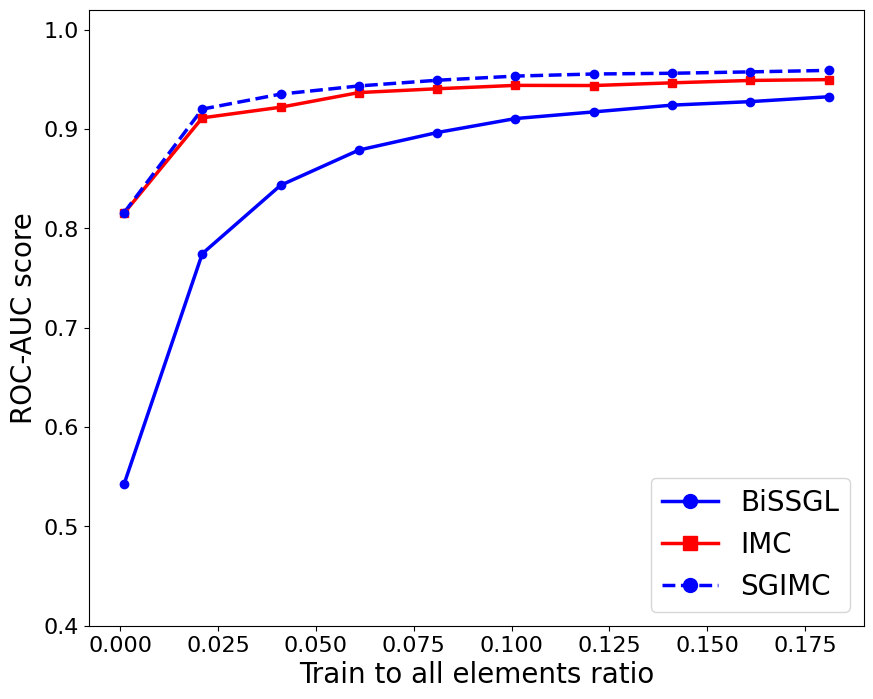

In [48]:
plt.figure(figsize=(10, 8))

# lines
bissgl_line = mlines.Line2D(
    [], [], color="blue", marker="o", linewidth=2.5, markersize=10, label="BiSSGL"
)
imc_line = mlines.Line2D(
    [], [], color="red", marker="s", linewidth=2.5, markersize=10, label="IMC"
)
sgimc_line = mlines.Line2D(
    [],
    [],
    color="blue",
    marker="o",
    linewidth=2.5,
    linestyle="--",
    markersize=10,
    label="SGIMC",
)

# curves
plt.plot(results_bissgl[0], results_bissgl[1], "b-", label="BiSSGL", linewidth=2.5)
plt.plot(results_imc[0], results_imc[1], "r-", label="IMC", linewidth=2.5)
plt.plot(results_sgimc[0], results_sgimc[1], "b--", label="SGIMC", linewidth=2.5)

# dotes
plt.plot(results_bissgl[0], results_bissgl[1], "bo", label="BiSSGL", linewidth=2.5)
plt.plot(results_imc[0], results_imc[1], "rs", label="IMC", linewidth=2.5)
plt.plot(results_sgimc[0], results_sgimc[1], "bo", label="SGIMC", linewidth=2.5)

# specify axis limits and labels
plt.ylim((0.4, 1.02))
plt.xlabel("Train to all elements ratio", fontsize=20)
plt.ylabel("ROC-AUC score", fontsize=20)

# ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# legend
plt.legend(
    handles=[
        bissgl_line,
        imc_line,
        sgimc_line,
    ],
    fontsize=20,
    loc=4,
)

plt.show()